In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install whitebox geopandas rasterio numpy scikit-image scipy opencv-python joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 52.7 MB/s eta 0:00:00


 # **Postprocessing**

 1. Noise reduction and gap filling
 2. Binarisation and cluster removal


In [ ]:
#HUOM! PITÄÄKÖ TUO LOHKOSÄÄNTÖ OLLA >25% VAI >40%?
#Alussa puhutiin 25, mutta postprocessing vaiheessa 40


import numpy as np
import rasterio
from skimage.restoration import denoise_bilateral
from scipy.ndimage import binary_dilation, label
from skimage.measure import block_reduce, regionprops

# ------------------------------
# 1. Aseta tiedostopolut
# ------------------------------
input_raster = "/content/drive/MyDrive/Random Forest_oma/ditch_probability_map_2.tif"
output_path = "/content/drive/MyDrive/Random Forest/ditch_postprocessed_full.tif"

# ------------------------------
# 2. Lue rasteri
# ------------------------------
with rasterio.open(input_raster) as src:
    prob = src.read(1)
    profile = src.profile
    prob = np.where(prob == src.nodata, np.nan, prob)

# ------------------------------
# 3. Bilateral de-noising filter
# ------------------------------
# Säilyttää lineaariset (oja-)muodot, mutta pehmentää satunnaista kohinaa
denoised = denoise_bilateral(
    prob,
    sigma_color=0.05, # määrittää kuinka paljon kirkkauseroja tasoitetaan (0.05 = kevyt suodatus)
    sigma_spatial=3,  # kertoo kuinka laaja-alueinen suodatus on
    channel_axis=None)
denoised = np.clip(denoised, 0, 1)

# ------------------------------
# 4. Outlier-pikselien poisto
# ------------------------------
# Poistetaan yksittäiset korkean arvon pikselit, jotka ovat kaukana muista
binary_high = (denoised > 0.7)
structure = np.ones((3, 3))
from scipy.ndimage import binary_erosion  # tarkistaa, onko pikseli osa suurempaa ryhmää
isolated = binary_high & ~binary_erosion(binary_high, structure)
denoised[isolated] = 0.1  # laske niiden arvoa, ei poista kokonaan

# ------------------------------
# 5. Gap filling (cone mask aggregation)
# ------------------------------

filled = denoised.copy()
for i in range(3):  # kolme kierrosta laajentaa noin 1.5–2.0 m suuntaansa
    filled = np.maximum(filled, binary_dilation(filled > 0.4, structure=structure) * 0.4)

# ------------------------------
# 6. Binarisation (≥25 % sääntö lohkoittain)  # 25 VAI 40??
# ------------------------------
block_size = 6  # 6x6 pikseliä → 3x3 m
block_mean = block_reduce(filled, block_size=(block_size, block_size), func=np.mean)
binarized = (block_mean >= 0.25).astype(np.uint8)

# ------------------------------
# 7. Cluster removal
# ------------------------------
labeled, num_features = label(binarized)
props = regionprops(labeled)

cleaned = np.zeros_like(binarized)
for prop in props:
    if prop.area >= 100:  # pidä vain suuret klusterit, TUTKIMUKSESSA 1500, mutta ainakin 1x1 m2 palalla se suodatti liikaa
        minr, minc, maxr, maxc = prop.bbox
        submask = (labeled[minr:maxr, minc:maxc] == prop.label)
        cleaned[minr:maxr, minc:maxc][submask] = 1

# ------------------------------
# 8. Tallenna tulos
# ------------------------------
new_transform = profile["transform"] * profile["transform"].scale(block_size, block_size)
profile.update(dtype="uint8", height=cleaned.shape[0], width=cleaned.shape[1],
               transform=new_transform, count=1, nodata=0, compress="deflate")

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(cleaned, 1)

print(f" Saved: {output_path}")


 Saved: /content/drive/MyDrive/Random Forest_oma/ditch_postprocessed_full.tif


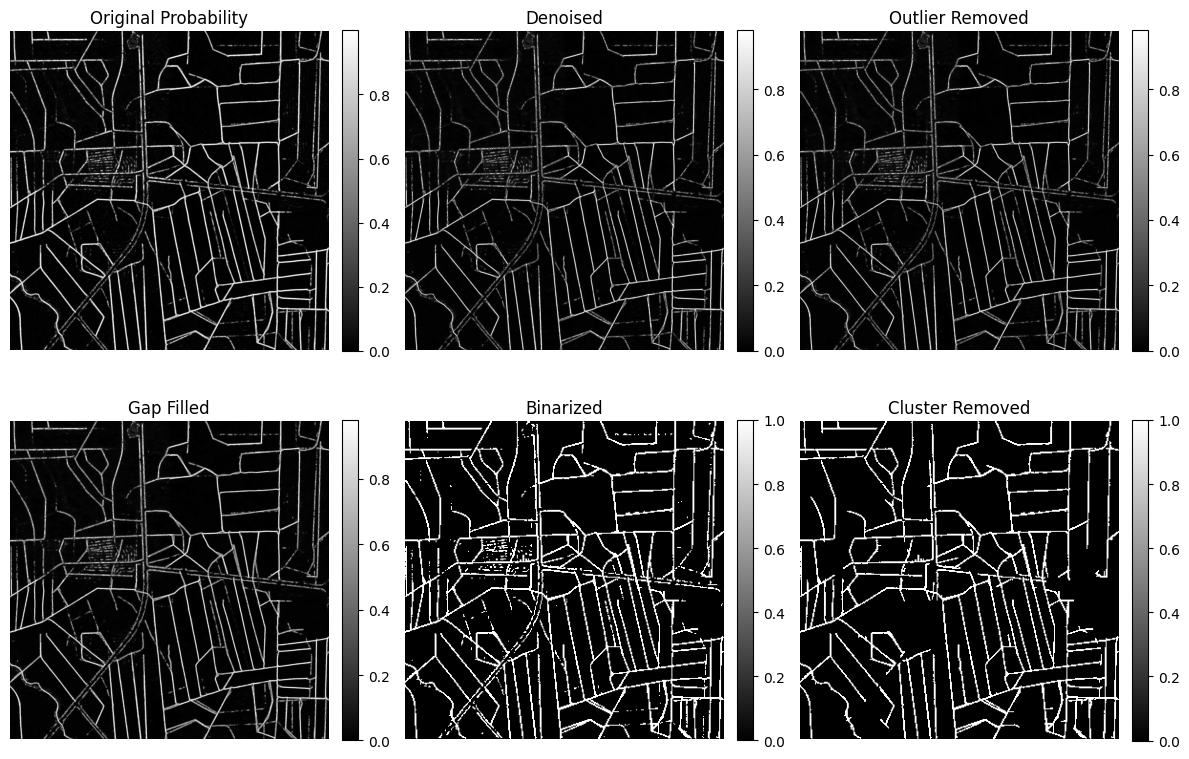

In [ ]:
# Visualisoi
import matplotlib.pyplot as plt

# Listataan kaikki kuvat ja niiden nimet
images = [
    (prob, "Original Probability"),
    (denoised, "Denoised"),
    (denoised.copy(), "Outlier Removed"),  # Käytetään denoisediä, koska poistetaan erillisesti
    (filled, "Gap Filled"),
    (binarized, "Binarized"),
    (cleaned, "Cluster Removed")
]

# Määritellään, että kolme kuvaa per rivi
n_cols = 3
n_rows = (len(images) + 1) // n_cols  # pyöristys ylöspäin

plt.figure(figsize=(12, n_rows * 4))  # säädetään koko

for i, (img, title) in enumerate(images):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    cmap = "gray" if img.ndim == 2 else None
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



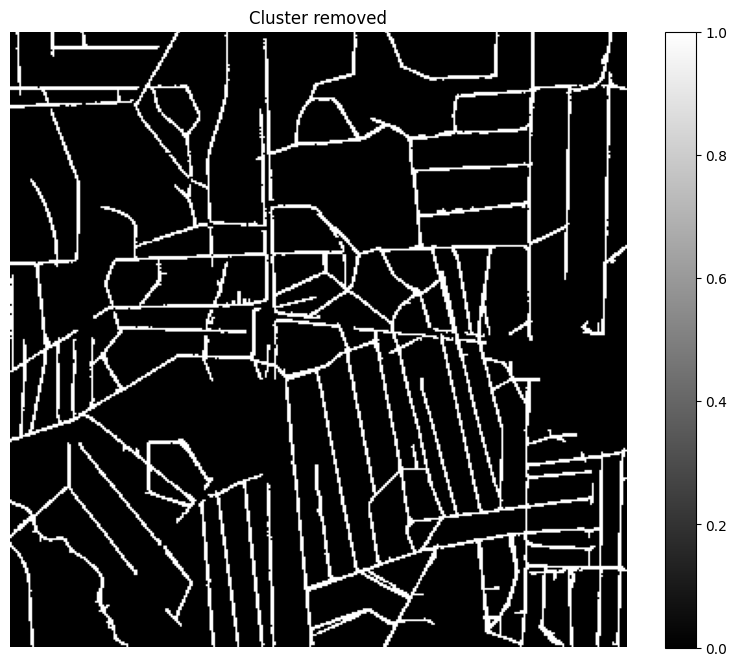

In [ ]:
import rasterio
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/Random Forest/ditch_postprocessed_full.tif"

with rasterio.open(file_path) as src:
    data = src.read(1)

plt.figure(figsize=(10, 8))        # Kuvion koko määritetään täällä
plt.imshow(data, cmap='gray')      # Näytetään rasteri
plt.colorbar()
plt.axis('off')
plt.title('Cluster removed')
plt.show()


In [ ]:
"""Tuosten arviointi"""

import numpy as np
import rasterio
from skimage.measure import block_reduce
from sklearn.metrics import precision_score, recall_score, cohen_kappa_score, average_precision_score, confusion_matrix

# ----------------------------------
# 1. Lue rasterit
# ----------------------------------
pred_fp = "/content/drive/MyDrive/Random Forest/ditch_postprocessed_full.tif"  # mallin tulos
ref_fp  = "/content/drive/MyDrive/Random Forest/DEM/ojat_label_grid.tif"       # referenssi

with rasterio.open(pred_fp) as src_pred:
    pred = src_pred.read(1)  # varmista että luetaan vain yksi bandi




with rasterio.open(ref_fp) as src_ref:
    ref = src_ref.read(1)

print("Pred shape:", pred.shape)
print("Ref shape before block reduce:", ref.shape)

# ----------------------------------
# 2. Tee referenssirasterille sama 6x6-lohkojen muunnos ja ≥25 % sääntö
# ----------------------------------
block_size = 6
ref_sum = block_reduce(ref, block_size=(block_size, block_size), func=np.sum)
ref_mean = ref_sum / (block_size**2)
ref_down = (ref_mean >= 0.25).astype(np.uint8)

print("Ref shape after block reduce:", ref_down.shape)

# ----------------------------------
# 3. Varmista että molemmat 2D ja leikkaa samankokoiseksi
# ----------------------------------
if pred.ndim != 2:
    raise ValueError(f"Prediction raster is not 2D (shape={pred.shape})")
if ref_down.ndim != 2:
    raise ValueError(f"Reference raster is not 2D (shape={ref_down.shape})")

min_rows = min(pred.shape[0], ref_down.shape[0])
min_cols = min(pred.shape[1], ref_down.shape[1])

pred = pred[:min_rows, :min_cols]
ref_down = ref_down[:min_rows, :min_cols]

print("Final aligned shapes:", pred.shape, ref_down.shape)

# ----------------------------------
# 4. Flatten ja laske mittarit
# ----------------------------------
pred = pred.ravel()
ref_down = ref_down.ravel()

precision = precision_score(ref_down, pred)
recall = recall_score(ref_down, pred)
kappa = cohen_kappa_score(ref_down, pred)
auprc = average_precision_score(ref_down, pred)
cm = confusion_matrix(ref_down, pred)

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("Cohen's kappa:", round(kappa, 3))
print("AUPRC:", round(auprc, 3))
print("Confusion matrix:\n", cm)


[0 1]
Pred shape: (334, 334)
Ref shape before block reduce: (333, 333)
Ref shape after block reduce: (56, 56)
Final aligned shapes: (56, 56) (56, 56)
Precision: 0.314
Recall: 0.135
Cohen's kappa: 0.02
AUPRC: 0.29
Confusion matrix:
 [[1974  264]
 [ 777  121]]
